In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv')

print("Shape:", df.shape)
df.head()

Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Daily Challenge — Breast Cancer Prediction

**Dataset:** Wisconsin Breast Cancer dataset (569 patients, 30 real features + id + diagnosis)

## Exploratory Data Analysis

In [2]:
df = df.drop(['id', 'Unnamed: 32'], axis=1)

print("Shape after dropping unnecessary columns:", df.shape)
print("\nMissing values remaining:", df.isnull().sum().sum())
print("\nDiagnosis value counts:")
print(df['diagnosis'].value_counts())

Shape after dropping unnecessary columns: (569, 31)

Missing values remaining: 0

Diagnosis value counts:
diagnosis
B    357
M    212
Name: count, dtype: int64


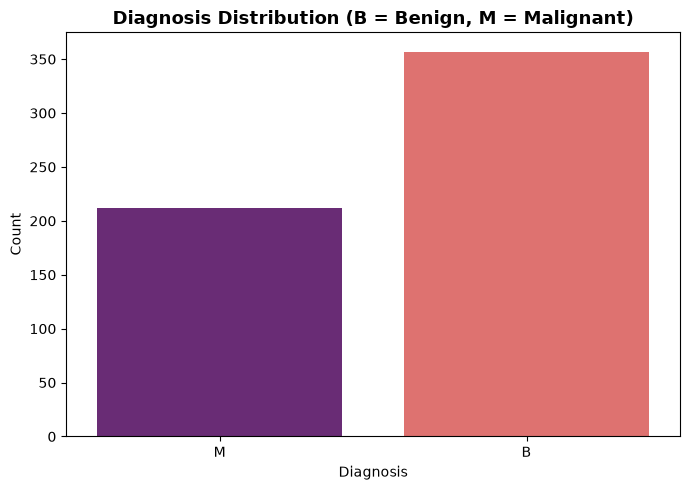

In [3]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='diagnosis', hue='diagnosis', palette='magma', legend=False)
plt.title('Diagnosis Distribution (B = Benign, M = Malignant)', fontsize=13, fontweight='bold')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Dataset is reasonably balanced (357 Benign, 212 Malignant — roughly 63%/37%), unlike the severe imbalance seen in the earlier Diabetes exercise. This means accuracy should be a trustworthy metric for comparing the 4 models without needing heavy reliance on precision/recall to catch a hidden issue.

## Data Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (455, 30)
Test shape: (114, 30)


## Building and Evaluating 4 Classification Models

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_accuracy = accuracy_score(y_test, log_model.predict(X_test_scaled))

# K Nearest Neighbors
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
knn_accuracy = accuracy_score(y_test, knn_model.predict(X_test_scaled))

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_accuracy = accuracy_score(y_test, rf_model.predict(X_test_scaled))

# SVM
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)
svm_accuracy = accuracy_score(y_test, svm_model.predict(X_test_scaled))

print(f"Logistic Regression Accuracy: {log_accuracy:.4f} ({log_accuracy*100:.2f}%)")
print(f"K Nearest Neighbors Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")
print(f"Random Forest Accuracy:       {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"SVM Accuracy:                 {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")

Logistic Regression Accuracy: 0.9649 (96.49%)
K Nearest Neighbors Accuracy: 0.9561 (95.61%)
Random Forest Accuracy:       0.9737 (97.37%)
SVM Accuracy:                 0.9737 (97.37%)


All 4 models perform excellently (95-97% accuracy), confirming this is a well-separated, "easy" dataset for classification — consistent with the reasonably balanced diagnosis split and clean numeric features. Random Forest and SVM tie for best at 97.37%, followed closely by Logistic Regression (96.49%) and KNN (95.61%).

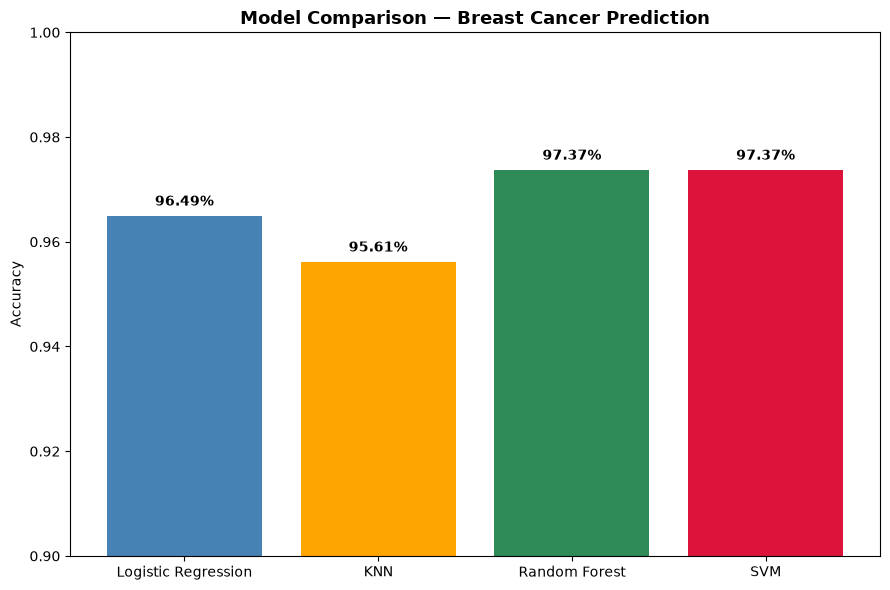

In [6]:
models = ['Logistic Regression', 'KNN', 'Random Forest', 'SVM']
accuracies = [log_accuracy, knn_accuracy, rf_accuracy, svm_accuracy]

plt.figure(figsize=(9, 6))
bars = plt.bar(models, accuracies, color=['steelblue', 'orange', 'seagreen', 'crimson'])
plt.ylim(0.9, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Comparison — Breast Cancer Prediction', fontsize=13, fontweight='bold')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{acc:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion: Which Model is Best?

**Random Forest and SVM tie for the best accuracy (97.37%)**, followed closely by Logistic Regression (96.49%) and KNN (95.61%). Given the near-identical top scores, either Random Forest or SVM would be a reasonable choice for this dataset.

**A note beyond pure accuracy:** as emphasized in the Diabetes Classification exercise, for a medical diagnosis task like this, Recall (catching real malignant cases) matters as much as or more than overall accuracy — a false negative (missing a real cancer diagnosis) is far costlier than a false positive (an unnecessary follow-up test). A complete evaluation would also check each model's confusion matrix and recall specifically for the Malignant class before making a final recommendation, rather than relying on accuracy alone.